In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'browser'

sns.set(style='whitegrid')

In [3]:
# Load the car sales dataset
df = pd.read_csv("/Users/sam/Documents/DI_DATA_2025/week10/xp&dc/USA_cars_datasets.csv")  # Replace with actual path if necessary
df.head()

,Unnamed: 0,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,0,6300,toyota,cruiser,2008,clean vehicle,274117.0,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,1,2899,ford,se,2011,clean vehicle,190552.0,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,2,5350,dodge,mpv,2018,clean vehicle,39590.0,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,3,25000,ford,door,2014,clean vehicle,64146.0,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,4,27700,chevrolet,1500,2018,clean vehicle,6654.0,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


In [4]:
# Check basic info and missing values
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    2499 non-null   int64  
 1   price         2499 non-null   int64  
 2   brand         2499 non-null   object 
 3   model         2499 non-null   object 
 4   year          2499 non-null   int64  
 5   title_status  2499 non-null   object 
 6   mileage       2499 non-null   float64
 7   color         2499 non-null   object 
 8   vin           2499 non-null   object 
 9   lot           2499 non-null   int64  
 10  state         2499 non-null   object 
 11  country       2499 non-null   object 
 12  condition     2499 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 253.9+ KB


Unnamed: 0      0
price           0
brand           0
model           0
year            0
title_status    0
mileage         0
color           0
vin             0
lot             0
state           0
country         0
condition       0
dtype: int64

In [6]:
# Remove rows with missing crucial info
df.dropna(subset=['price', 'brand', 'condition', 'mileage'], inplace=True)

# Convert Price and Mileage to numeric if needed
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

# Drop rows with invalid values
df.dropna(subset=['price', 'mileage'], inplace=True)


Histogram: Car Price Distribution

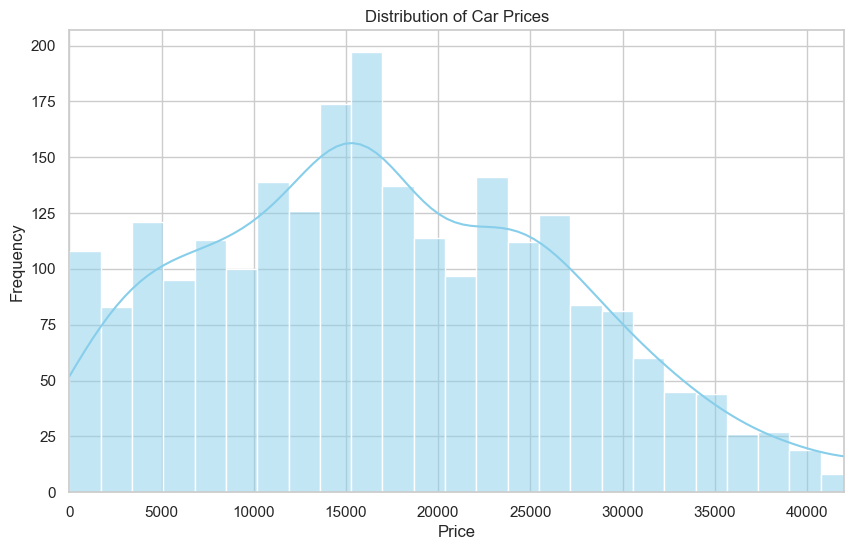

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xlim(0, df['price'].quantile(0.95))  # Exclude extreme outliers
plt.show()

Box Plot: Price by Brand (Top 10)

/var/folders/98/72mf16fn6sv4h6j6pj3w1__h0000gn/T/ipykernel_42806/891644262.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='brand', y='price', palette='Set2')


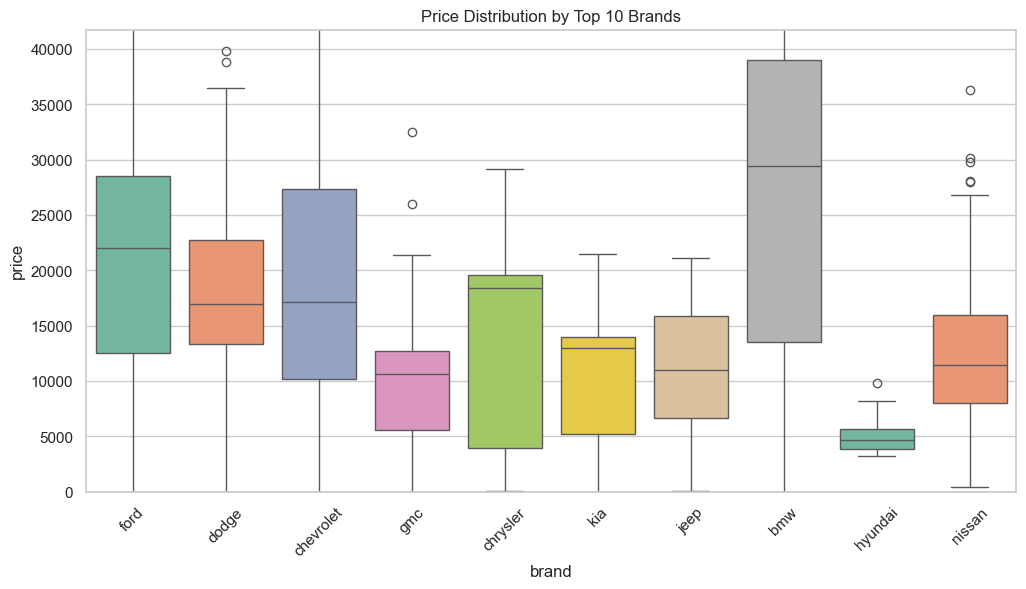

In [11]:
# Get top 10 most common brands
top_brands = df['brand'].value_counts().nlargest(10).index

# Filter for top brands
df_top = df[df['brand'].isin(top_brands)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top, x='brand', y='price', palette='Set2')
plt.title('Price Distribution by Top 10 Brands')
plt.ylim(0, df_top['price'].quantile(0.95))  # Focus on reasonable range
plt.xticks(rotation=45)
plt.show()

Interactive Scatter Plot: Price vs Mileage by Condition

In [21]:
import plotly.express as px
import plotly.io as pio

# Use browser instead of notebook for rendering
pio.renderers.default = 'browser'

# Create interactive scatter plot
fig = px.scatter(
    df,
    x='mileage',
    y='price',
    color='condition',
    title='price vs mileage colored by condition',
    hover_data=['brand', 'model', 'year'],
    labels={'mileage': 'mileage (miles)', 'price': 'price ($)'},
    opacity=0.6
)

fig.update_layout(height=600)
fig.show()


Optional: Heatmap of Avg Price by Brand and Condition

In [24]:
print(df['condition'].unique())

['10 days left' '6 days left' '2 days left' '22 hours left'
 '20 hours left' '19 hours left' '3 days left' '21 hours left'
 '17 hours left' '2 hours left' '3 hours left' '34 minutes'
 '16 hours left' '18 hours left' '1 days left' '32 minutes'
 '14 hours left' '5 hours left' '4 days left' '9 days left'
 '23 hours left' '8 days left' '7 days left' '5 days left' '9 minutes'
 '1 minutes' '7 hours left' '16 minutes' '6 hours left' '1 hours left'
 'Listing Expired' '13 days left' '24 hours left' '15 hours left'
 '53 minutes' '27 minutes' '12 days left' '15 days left' '30 minutes'
 '29 minutes' '28 minutes' '48 minutes' '11 days left' '4 hours left'
 '47 minutes' '12 hours left' '36 minutes']


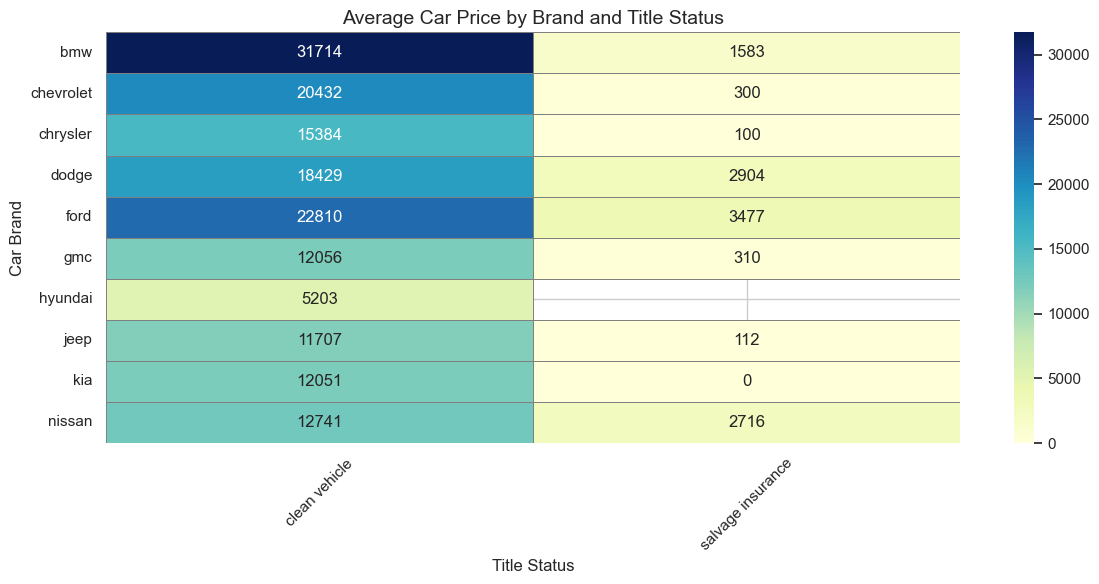

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select top 10 most frequent brands
top_brands = df['brand'].value_counts().nlargest(10).index
filtered_df = df[df['brand'].isin(top_brands)]

# Create a pivot table: average price by brand and title status
pivot_table = filtered_df.pivot_table(
    values='price',
    index='brand',
    columns='title_status',
    aggfunc='mean'
)

# Plot the heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap='YlGnBu', linewidths=0.5, linecolor='gray')

plt.title('Average Car Price by Brand and Title Status', fontsize=14)
plt.xlabel('Title Status', fontsize=12)
plt.ylabel('Car Brand', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()